In [126]:
import sklearn.datasets as sk
import pandas as pd

data = sk.load_diabetes()
df = pd.DataFrame(data=data.data,columns=data.feature_names)
df = df[df.columns[df.dtypes != "object"]]
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scale = pd.DataFrame(data=scaler.fit_transform(df),columns=data.feature_names)
df_scale.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000,4.420000e+02
mean,-8.037814e-18,2.290777e-16,2.009453e-17,-1.607563e-17,8.037814e-18,4.018907e-18,-4.018907e-18,2.330966e-16,0.000000,-4.018907e-17
std,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133,1.001133e+00
min,-2.254290e+00,-9.385367e-01,-1.897929e+00,-2.363050e+00,-2.665411e+00,-2.430626e+00,-2.150883e+00,-1.606102e+00,-2.651040,-2.896390e+00
25%,-7.841722e-01,-9.385367e-01,-7.196249e-01,-7.706500e-01,-7.200196e-01,-6.382488e-01,-7.382960e-01,-8.303008e-01,-0.698949,-6.975491e-01
50%,1.131724e-01,-9.385367e-01,-1.531324e-01,-1.192138e-01,-9.084100e-02,-8.029125e-02,-1.384305e-01,-5.449919e-02,-0.040937,-2.265729e-02
75%,8.005001e-01,1.065488e+00,6.569519e-01,7.493678e-01,5.961931e-01,6.274425e-01,6.162390e-01,7.213025e-01,0.681851,5.869224e-01
max,2.327895e+00,1.065488e+00,3.585718e+00,2.776058e+00,3.235851e+00,4.179278e+00,3.809072e+00,3.894331e+00,2.808722,2.851075e+00


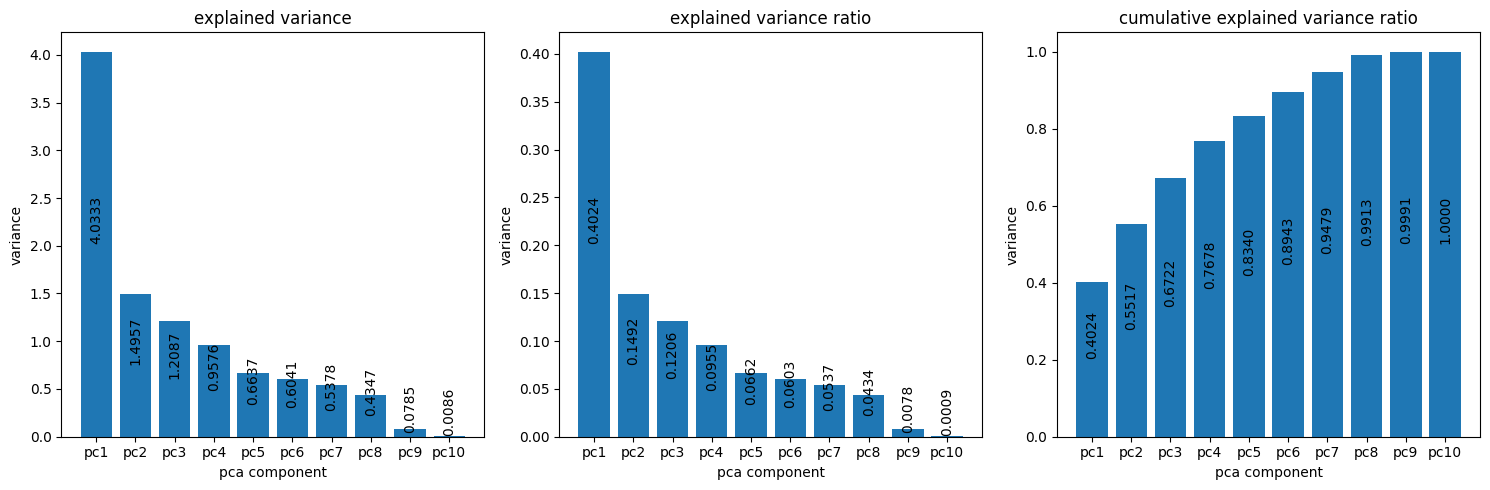

In [128]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(df_scale)

labels = [f"pc{i+1}" for i in range(X_pca.shape[1])]
cumsum = np.cumsum(pca.explained_variance_ratio_)

def plot_bar(ax, values, title):
    bars = ax.bar(labels, values)
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h/2,
            f"{h:.4f}",
            ha='center',
            va='bottom',
            rotation='vertical'
        )
    ax.set_title(title)
    ax.set_xlabel("pca component")
    ax.set_ylabel("variance")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_bar(axes[0], pca.explained_variance_, "explained variance")
plot_bar(axes[1], pca.explained_variance_ratio_, "explained variance ratio")
plot_bar(axes[2], cumsum, "cumulative explained variance ratio")

plt.tight_layout()
plt.show()

<Axes: >

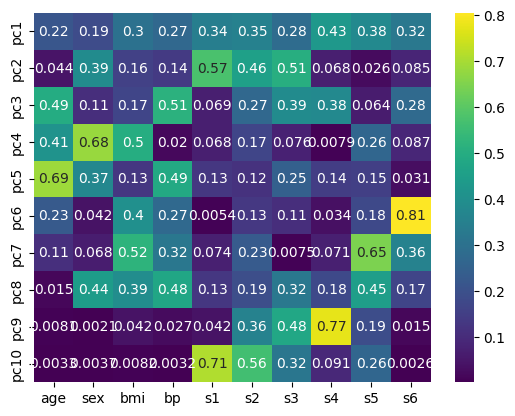

In [129]:
import seaborn as sn

loading = pd.DataFrame(abs(pca.components_),[f"pc{i+1}" for i in range(pca.n_components_)] ,columns=df.columns)

sn.heatmap(loading,annot=True,cmap="viridis")

<Axes: >

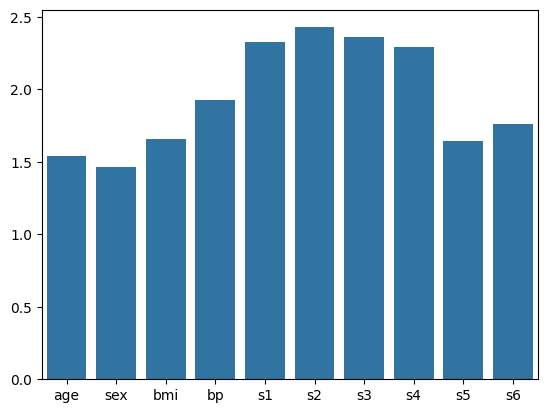

In [130]:
k_component = 3

importance = (pca.explained_variance_[:k_component, None] * loading.iloc[:k_component,:]).sum()

sn.barplot(importance)

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10,target
0,0.587199,-1.946832,0.589205,0.082816,0.256680,-1.011210,-0.179844,-0.757431,-0.181075,-0.048953,151.0
1,-2.831625,1.372082,0.027930,0.470008,0.143269,-1.013015,0.224398,0.188436,0.505128,0.043599,75.0
2,0.272129,-1.634901,0.739244,0.791492,1.163870,-1.112763,-0.462452,-0.843203,-0.025353,-0.054175,141.0
3,0.049281,0.382278,-2.013032,-1.373216,-0.255570,0.445288,0.482102,0.367871,-0.137857,-0.074558,206.0
4,-0.756421,0.811960,-0.057238,0.137495,0.133402,-0.814559,0.436536,1.059751,0.044284,-0.010914,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,1.239525,-1.035968,0.928679,0.656264,-0.204296,-0.479385,0.394415,-0.126490,-0.377893,-0.025229,178.0
438,1.264719,0.761319,-1.750191,1.133464,0.093975,0.973445,-1.173498,-0.180439,-0.371759,0.033447,104.0
439,-0.205206,-1.205487,0.496186,1.353370,0.141574,-0.045351,-0.635396,0.491849,-0.113220,0.058875,132.0
440,0.692871,0.210127,-0.868724,-1.616793,-0.119624,-0.556907,0.545701,-0.078684,-0.127211,-0.045540,220.0


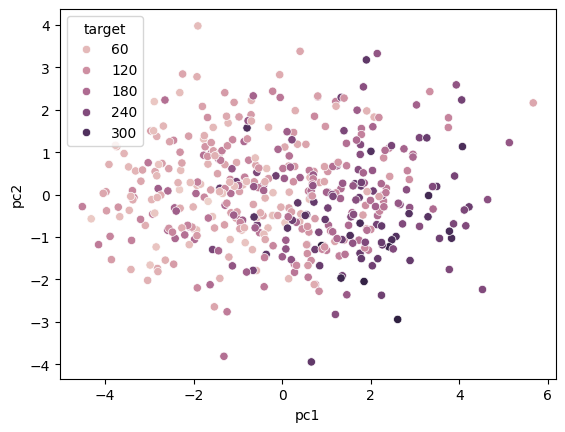

In [131]:
df_pca = pd.DataFrame(X_pca, columns=labels)
df_pca["target"] = data.target
sn.scatterplot(data=pd.DataFrame(df_pca,columns=labels),x="pc1",y="pc2",hue=df_pca.target)
pd.DataFrame(df_pca)